# `q_by_h.ipynb`: replica overlap $q$ by temperature

In [1]:
import jax
from jax import numpy as jnp
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
from pathlib import Path

from utils.modelIO import *
from utils.phases import *

initialize

In [2]:
GIDS_PATH = Path('data/eml/eml_gene_ids.csv')
BIO_GRN_PATH = Path('data/eml/eml_fate_network.npy')
BIO_SIM_PATH = Path('results/eml/bio_h_vary/')
FIG_SAVE_PATH = Path('figs/eml/')

_, _, N = load_grn(BIO_GRN_PATH, GIDS_PATH)
fields = jnp.arange(-6, 7, 1)

load final states, using only 100 replicates so that memory use doesn't get too crazy

In [3]:
def load_bio_h_final_states(h):
    path = BIO_SIM_PATH.joinpath('bio_h_{}_xs.npy'.format(h.astype(int)))
    return jnp.load(path)[:, -1][:100]
bio_xs = jnp.array([load_bio_h_final_states(h) for h in fields])

estimate overlaps

In [4]:
def get_all_qab_fix_N(grn_states):
    return get_all_qab(grn_states, N)
get_all_qab_h_vmap = jax.vmap(get_all_qab_fix_N)
bio_qabs = get_all_qab_h_vmap(bio_xs)

make violin plot

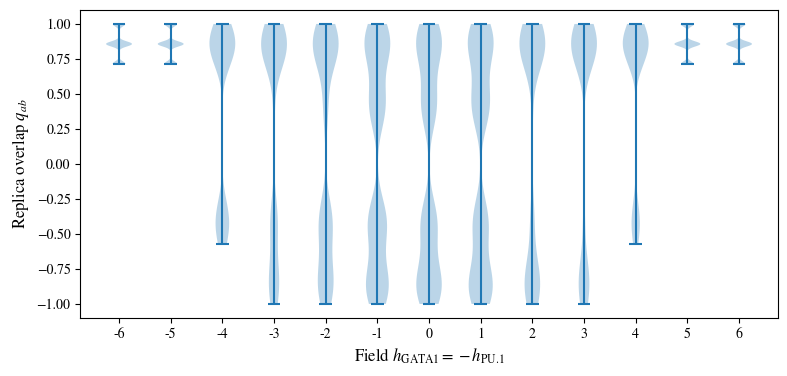

In [5]:
def set_axis_style(ax, labels):
    ax.set_xticks(jnp.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel(r'Field $h_\text{GATA1} = -h_\text{PU.1}$', fontsize=12)

fig, ax = plt.subplots(figsize=(9, 4))
ax.set_ylabel(r'Replica overlap $q_{ab}$', fontsize=12)
ax.violinplot(bio_qabs.T)
set_axis_style(ax, fields.astype(int))
plt.savefig(FIG_SAVE_PATH.joinpath('q_by_h.pdf'), bbox_inches='tight')